In [2]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from ipycanvas import Canvas
from ipywidgets import VBox, Button
from IPython.display import display

In [3]:
train_dataset = torchvision.datasets.MNIST(root="data/", train=True, download=True)
test_dataset = torchvision.datasets.MNIST(root="data/", train=False, download=True)

X_train = train_dataset.data.numpy().astype(np.float32).reshape(len(train_dataset), -1) / 255.0
y_train = np.eye(10)[train_dataset.targets.numpy().astype(np.int32)]

X_test = test_dataset.data.numpy().astype(np.float32).reshape(len(test_dataset), -1) / 255.0
y_test = np.eye(10)[test_dataset.targets.numpy().astype(np.int32)]

In [4]:
def relu(x):
    return np.maximum(0, x)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp = np.exp(x)
    return exp / np.sum(exp, axis=1, keepdims=True)

In [5]:
class Layer():
    def __init__(self, shape, activation=True):
        self.weights =  np.random.randn(*shape) * np.sqrt(2 / shape[0])
        self.biases = np.zeros((1,shape[1]))
        self.activation = activation

    def print(self):
        print(self.weights)
        print()
        print(self.biases)
        
    def forward(self, X):
        self.input = X
        self.z = np.dot(self.input, self.weights) + self.biases
        self.a = relu(self.z) if self.activation else self.z
        return self.a
    
    def updateParams(self, dw, db, lr):
        self.weights -= dw * lr
        self.biases -= db * lr
    
    def backward(self, gradOut, learningRate):
        da = (self.z > 0) if self.activation else 1
        dz = gradOut * da

        dw = np.dot(self.input.T, dz) / dz.shape[0]
        db = np.sum(dz, axis=0, keepdims=True) / dz.shape[0]

        self.updateParams(dw, db, learningRate)

        gradInput = np.dot(dz, self.weights.T)
        return gradInput

In [6]:
class Network():
    def __init__(self, layerSizes):
        self.layers = []
        for i in range(len(layerSizes)-1):
            activation = i != len(layerSizes)-2
            self.layers.append(Layer((layerSizes[i], layerSizes[i+1]), activation))
        
    def printparams(self):
        """prints all network info"""
        for i, layer in enumerate(self.layers):
            print(f"\n Layer {i+1}:")
            print(f"Weights: {layer.weights[0][:5]}...")
            print(f"Biases: {layer.biases[0][:5]}...")
    
    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return softmax(X)
    
    def test(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X
    
    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)
    
    def train(self, X, Y, X_test, Y_test, learningRate, epochs, batchSize):
        losses = []
        accuracies = []

        n = len(X)

        for epoch in range(epochs):
            totalLoss = 0
            indices = np.random.permutation(n)

            for i in range(0, n, batchSize):
                batchIdx = indices[i:i+batchSize]
                x = X[batchIdx]
                y = Y[batchIdx]
                
                y_hat = self.forward(x)
                grad = y_hat - y
                
                for layer in reversed(self.layers):
                    grad = layer.backward(grad, learningRate)
                
                totalLoss += - np.sum(y * np.log(y_hat + 1e-12))
        
            loss = totalLoss / n
            
            preds = np.argmax(self.forward(X_test), axis=1)
            true = np.argmax(Y_test, axis=1)
            accuracy = np.mean(preds == true)

            losses.append(loss)
            accuracies.append(accuracy)
            
            if (epoch+1) % 10 == 0:
                print(f"Epoch {epoch+1}: Loss={loss:.4f}  Test Accuracy={accuracy:.4f}")

        return losses, accuracies

In [7]:
model = Network((784, 128, 10))

losses, accs = model.train(X_train, y_train, X_test, y_test, 0.01, 100, 64)

Epoch 10: Loss=0.2286  Test Accuracy=0.9389
Epoch 20: Loss=0.1633  Test Accuracy=0.9536
Epoch 30: Loss=0.1270  Test Accuracy=0.9621
Epoch 40: Loss=0.1038  Test Accuracy=0.9669
Epoch 50: Loss=0.0876  Test Accuracy=0.9694
Epoch 60: Loss=0.0755  Test Accuracy=0.9708
Epoch 70: Loss=0.0661  Test Accuracy=0.9725
Epoch 80: Loss=0.0586  Test Accuracy=0.9733
Epoch 90: Loss=0.0524  Test Accuracy=0.9746
Epoch 100: Loss=0.0471  Test Accuracy=0.9753


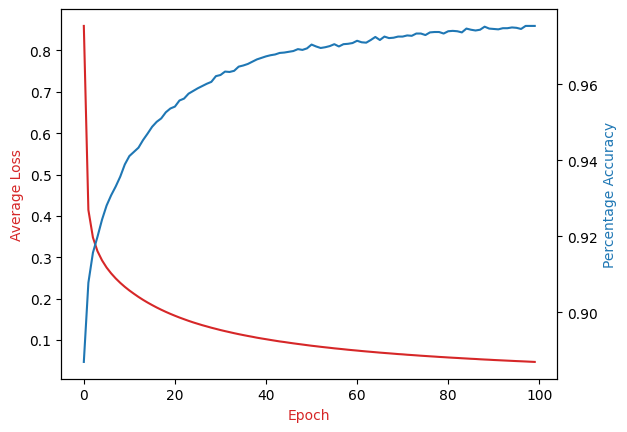

In [8]:
fig, ax1 = plt.subplots()

lossColor = "tab:red"
ax1.plot(losses, color=lossColor)
ax1.set_xlabel("Epoch", color=lossColor)
ax1.set_ylabel("Average Loss", color=lossColor)

accuracyColor = "tab:blue"
ax2 = ax1.twinx()
ax2.plot(accs, color=accuracyColor)
ax2.set_ylabel("Percentage Accuracy", color=accuracyColor)
plt.show()

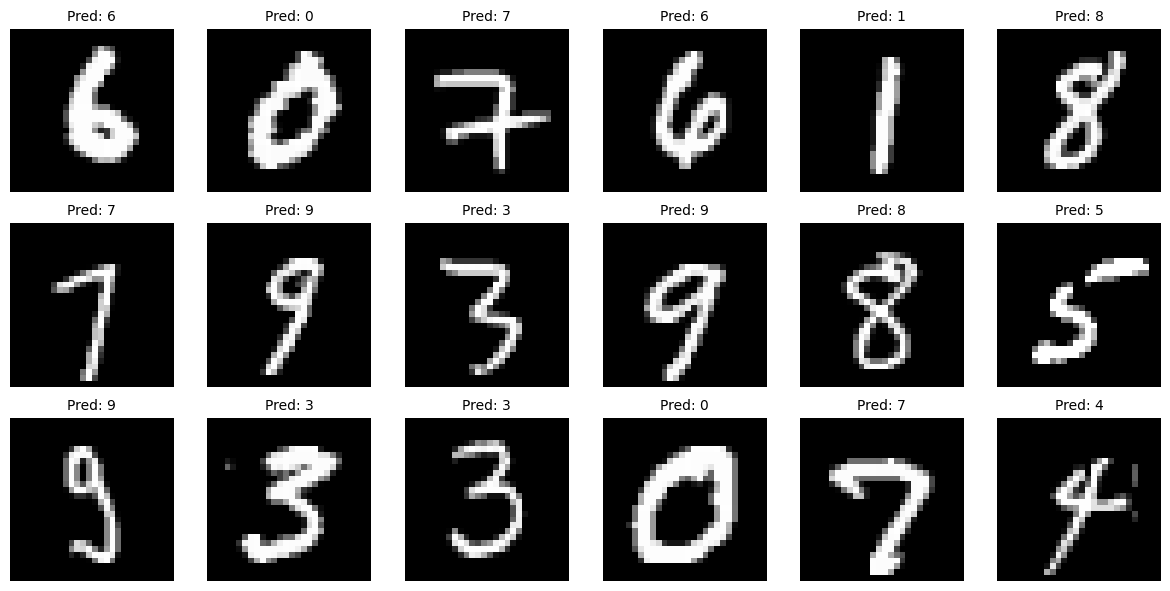

In [9]:
offset = 2

fig, ax = plt.subplots(3, 6, figsize=(12,6))
for i in range(3):
    for j in range(6):
        idx = i*6 + j + offset*3*6
        img = train_dataset.data[idx].numpy()
        ax[i, j].imshow(img, cmap='gray')
        ax[i, j].axis('off')
        
        x = img.reshape(1, -1) / 255.0
        pred = model.predict(x)[0]
        ax[i, j].set_title(f"Pred: {pred}", fontsize=10)

plt.tight_layout()
plt.show()

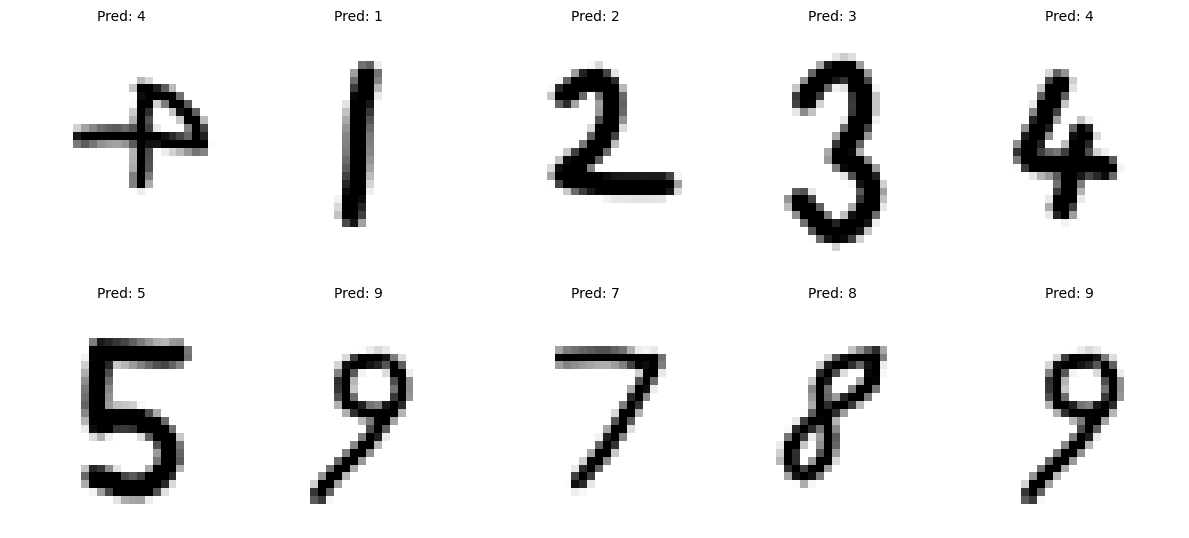

In [10]:
fig, ax = plt.subplots(2, 5, figsize=(12,6))

for i in range(2):
    for j in range(5):
        idx = i*5 + j
        img = Image.open(f"testImages/{i*5+j}.png")
        ax[i, j].imshow(img, cmap='gray')
        ax[i, j].axis('off')
        
        x = 1-np.array(Image.open(f"testImages/{i*5+j}.png").convert("L")).reshape(1, 784) / 255.0
        pred = model.predict(x)[0]
        ax[i, j].set_title(f"Pred: {pred}", fontsize=10)

plt.tight_layout()
plt.show()

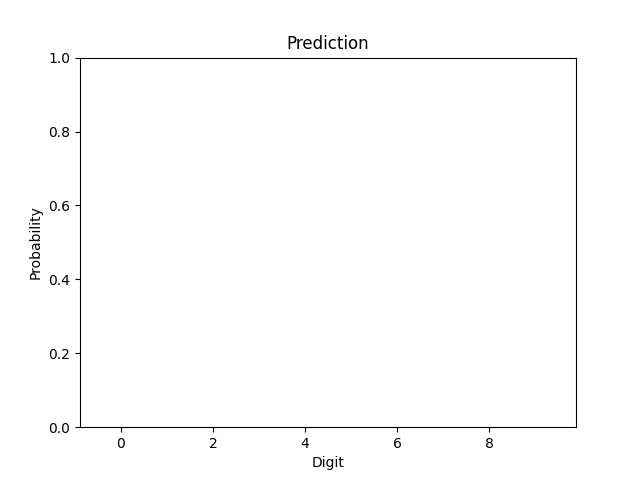

In [13]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ipycanvas import Canvas
from ipywidgets import VBox, Button
from IPython.display import display

# Smaller canvas for Jupyter
canvas_size = 140

# Enable sync_image_data=True so get_image_data() works
canvas = Canvas(width=canvas_size, height=canvas_size, sync_image_data=True)

canvas.fill_style = "black"
canvas.fill_rect(0,0,canvas_size,canvas_size)

canvas.stroke_style = "white"
canvas.line_width = 12
canvas.line_cap = "round"

drawing = False

# Create bar chart
fig, ax = plt.subplots()
bars = ax.bar(np.arange(10), np.zeros(10))
ax.set_ylim(0,1)
ax.set_xlabel("Digit")
ax.set_ylabel("Probability")
ax.set_title("Prediction")

def update_prediction():
    # Get canvas image and convert to 28x28
    img = np.array(canvas.get_image_data(0,0,canvas_size,canvas_size).data)
    img = img.reshape(canvas_size,canvas_size,4)[:,:,0]  # only red channel

    img = Image.fromarray(img).resize((28,28))
    img = np.array(img)

    img = 1 - img/255.0
    img = img.reshape(1,784)

    # Predict
    probs = model.forward(img)[0]

    # Update bars
    for i,b in enumerate(bars):
        b.set_height(probs[i])
    ax.set_title(f"Prediction: {np.argmax(probs)}")
    fig.canvas.draw_idle()

# Mouse event handlers
def mouse_down(x,y):
    global drawing
    drawing = True
    canvas.begin_path()
    canvas.move_to(x,y)

def mouse_move(x,y):
    if drawing:
        canvas.line_to(x,y)
        canvas.stroke()
        update_prediction()  # update while drawing

def mouse_up(x,y):
    global drawing
    drawing = False
    update_prediction()

canvas.on_mouse_down(mouse_down)
canvas.on_mouse_move(mouse_move)
canvas.on_mouse_up(mouse_up)

# Clear button
clear_button = Button(description="Clear")
def clear(_):
    canvas.fill_style = "black"
    canvas.fill_rect(0,0,canvas_size,canvas_size)
    update_prediction()
clear_button.on_click(clear)

display(VBox([canvas, clear_button]))